In [1]:
import numpy as np
import itertools

def analytical_memory_kernel(t: np.ndarray, init_config: dict, θ: np.ndarray, n_spec: int):

    # 1. Unpack parameters (reusing your safe unpacking logic)
    γ_φ    = np.abs(θ[:n_spec+1])
    γ_down = np.abs(θ[n_spec+1])
    J_0q   = θ[n_spec+2 : 2*n_spec+2]
    ω_0    = θ[2*n_spec+2]
    
    Γ_0 = 2 * γ_φ[0] + 0.5 * γ_down
    Γ_q = γ_φ[1:]
    z_spec = init_config["z-spec"]
    
    # 2. Base rate of the main qubit
    # \xi(t) starts with exp(-(\Gamma_0 - i\omega_0)t)
    S_base = -Γ_0 + 1j * ω_0
    
    # 3. Build the exponential branches for each spectator
    components = []
    for q in range(n_spec):
        G = Γ_q[q]
        J = J_0q[q]
        z = z_spec[q]
        
        Omega = G / 2.0 - 1j * J
        
        # Calculate R_q coefficient safely
        if np.abs(Omega) > 1e-12:
            R = (G / 2.0 - 1j * z * J) / Omega
        else:
            R = 1.0 + 0j
            
        # The two exponential weights and rates for this spectator
        A_q = (1.0 + R) / 2.0
        B_q = (1.0 - R) / 2.0
        
        alpha_plus = -1j * J
        alpha_minus = -G + 1j * J
        
        components.append([(A_q, alpha_plus), (B_q, alpha_minus)])
        
    # 4. Cartesian product to get all 2^N = 8 exponential terms
    W_j = []
    S_j = []
    for terms in itertools.product(*components):
        w = 1.0
        s = S_base
        for (wq, sq) in terms:
            w *= wq  # Multiply the weights
            s += sq  # Add the exponents
        W_j.append(w)
        S_j.append(s)
        
    W_j = np.array(W_j, dtype=complex)
    S_j = np.array(S_j, dtype=complex)
    
    # 5. Form the polynomial N(s) from F(s) = N(s)/D(s) = \sum W_j / (s - S_j)
    # First, get the coefficients of D(s) = \prod (s - S_j)
    D_coeffs = np.poly(S_j)
    
    # Now build N(s) by polynomial division
    N_coeffs = np.zeros(len(S_j), dtype=complex)
    for j in range(len(S_j)):
        # D(s) / (s - S_j) perfectly divides without remainder
        Q_coeffs, _ = np.polydiv(D_coeffs, [1.0, -S_j[j]])
        N_coeffs += W_j[j] * Q_coeffs
        
    # 6. The poles of the memory kernel are exactly the roots of N(s)
    r_k = np.roots(N_coeffs)
    
    # 7. Calculate the Residues c_k = -1 / F'(r_k)
    def F_prime(s):
        return -np.sum(W_j / (s - S_j)**2)
    
    c_k = np.array([-1.0 / F_prime(r) for r in r_k])
    
    # 8. Construct the exact k(t) = \sum c_k e^{r_k t}
    k_t = np.zeros_like(t, dtype=complex)
    for c, r in zip(c_k, r_k):
        k_t += c * np.exp(r * t)
        
    return k_t

In [2]:
import re
from pathlib import Path
import jax
import jax.numpy as jnp
import optax
import pandas as pd
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

# -----------------------------------------------------------------------------
#  Utility : initial-state parsing
# -----------------------------------------------------------------------------

def _state_to_bloch(label: str):
    """Return (x,y,z) Bloch coords for |+>, |->, |0>, |1>, |+i>, |-i>."""
    label = label.strip()
    bloch_map = {
        "+":  ( 1.0,  0.0,  0.0),
        "-":  (-1.0,  0.0,  0.0),
        "+i": ( 0.0,  1.0,  0.0),
        "-i": ( 0.0, -1.0,  0.0),
        "0":  ( 0.0,  0.0,  1.0),
        "1":  ( 0.0,  0.0, -1.0),
    }
    if label not in bloch_map:
        raise ValueError(f"Unknown qubit label '{label}'.")
    return bloch_map[label]


def parse_initial_state(path: str | Path, n_spec: int):
    """Extract main and spectator Bloch vectors from filename using regex."""
    path_str = str(path)
    
    # Safely extract the init string (e.g., 'init+,+,+,+' -> '+,+,+,+')
    match = re.search(r"init([^/]+)", path_str)
    if not match:
        raise RuntimeError(f"Filename must contain 'init<prep_string>/' segment. Found: {path_str}")
    
    labels = match.group(1).split(",")
    if len(labels) != n_spec + 1:
        raise ValueError(f"Expected {n_spec+1} qubit labels, found {len(labels)} in '{match.group(1)}'.")

    # main qubit first
    x0, y0, z0 = _state_to_bloch(labels[0])
    spectator_xyz = jnp.array([_state_to_bloch(l) for l in labels[1:]])  # (N,3)
    z_spec = spectator_xyz[:, 2]                                         # (N,)
    
    return jnp.asarray([x0, y0, z0], dtype=jnp.float64), z_spec

# -----------------------------------------------------------------------------
#  Analytic Σ₀⁺(t) and Bloch-vector functions
# -----------------------------------------------------------------------------

def _unpack_theta(θ, n_spec: int):
    """Safely unpack the parameter vector to avoid indexing bugs."""
    # Enforce positivity for decay rates using absolute value
    γ_φ    = jnp.abs(θ[:n_spec+1])           # (n_spec + 1,)
    γ_down = jnp.abs(θ[n_spec+1])            # Scalar
    J_0q   = θ[n_spec+2 : 2*n_spec+2]        # (n_spec,)
    ω_0    = θ[2*n_spec+2]                   # Scalar
    return γ_φ, γ_down, J_0q, ω_0


def sigma_plus_general(t, x0, y0, ω0, Γ0, J_0q, Γq, zq):
    """Analytic Σ₀⁺(t) for arbitrary spectator preparations."""
    t = t[None, :]                     # broadcast (1,T)
    Σ = 0.5 * (x0 - 1j * y0) * jnp.exp(-(Γ0 - 1j * ω0) * t)

    if J_0q.size > 0:
        Jq = J_0q[:, None]
        Γq = Γq[:, None]
        zq = zq[:, None]
        Ωq  = Γq / 2.0 - 1j * Jq
        eps = 1e-12
        absΩ = jnp.abs(Ωq)
        Cq  = jnp.cosh(Ωq * t)
        Sq  = jnp.sinh(Ωq * t)
        
        ratio = jnp.where(absΩ > eps, (Γq/2.0 - 1j*zq*Jq)/Ωq, 1.0 + 0.0j)
        bracket = jnp.where(absΩ > eps, Cq + ratio*Sq, 1.0 + (Γq/2.0 - 1j*zq*Jq)*t)
        
        Σ *= jnp.exp(-Γq * t / 2.0).prod(axis=0) * bracket.prod(axis=0)

    return Σ.squeeze(0)               # (T,)


def bloch_from_parameters(t, init_config, θ, n_spec):
    """Decode parameter vector θ → Bloch vector array (3,T)."""
    x0, y0, z0 = init_config["bloch-main"]
    z_spec = init_config["z-spec"]
    
    γ_φ, γ_down, J_0q, ω_0 = _unpack_theta(θ, n_spec)
    
    Γ_0 = 2 * γ_φ[0] + 0.5 * γ_down
    Γ_q = γ_φ[1:]

    Σ  = sigma_plus_general(t, x0, y0, ω_0, Γ_0, J_0q, Γ_q, z_spec)
    vx =  2.0 * Σ.real
    vy = -2.0 * Σ.imag
    vz = 1 + (z0 - 1) * jnp.exp(-γ_down * t)

    return jnp.stack([vx, vy, vz])    # (3,T)

# -----------------------------------------------------------------------------
#  Fitting routine
# -----------------------------------------------------------------------------

def fit_crosstalk(csv_path: str | Path,
                  n_spec: int,
                  lr: float = 1e-2,
                  steps: int = 5000,
                  seed: int = 0,
                  plot: bool = False,
                  verbose: bool = False):
    """Fit ZZ-crosstalk parameters to a CSV containing Bloch trajectories."""
    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path)

    t_exp = jnp.asarray(df["t_us"].to_numpy(), dtype=jnp.float64)
    bloch_exp = jnp.asarray(df[["X_mean", "Y_mean", "Z_mean"]].to_numpy().T, dtype=jnp.float64)

    bloch0_main, z_spec_init = parse_initial_state(csv_path, n_spec)
    init_config = {
        'bloch-main': bloch0_main, 
        'z-spec': z_spec_init,     
    }

    # ---- build initial θ --------------------------------------------------
    key = jax.random.PRNGKey(seed)
    θ   = jax.random.normal(key, (3 + 2 * n_spec,)) * 0.05  # small noise

    # ---- loss -------------------------------------------------------------
    def loss_fn(θ):
        pred = bloch_from_parameters(t_exp, init_config, θ, n_spec)
        return jnp.mean((pred - bloch_exp) ** 2)

    opt = optax.adam(lr)
    opt_state = opt.init(θ)

    @jax.jit
    def step(θ, opt_state):
        l, g = jax.value_and_grad(loss_fn)(θ)
        updates, opt_state = opt.update(g, opt_state, θ)
        θ = optax.apply_updates(θ, updates)
        return θ, opt_state, l

    for k in range(steps):
        θ, opt_state, L = step(θ, opt_state)
        if verbose and k % 100 == 0:
            print(f"[{k:5d}] loss = {float(L):.5e}")

    # ---- results ----------------------------------------------------------
    print("\nFitted parameters (physical values)")
    γ_φ, γ_down, J_0q, ω_0 = _unpack_theta(θ, n_spec)
    
    for q in range(n_spec + 1):
        print(f"γ_φ{q:<5} = {float(γ_φ[q]):.6g}")
    print(f"γ_↓     = {float(γ_down):.6g}")
    for q in range(n_spec):
        print(f"J_0{q+1:<4} = {float(J_0q[q]):.6g}")
    print(f"ω_0     = {float(ω_0):.6g}")
    
    print(f"Final weighted MSE  = {float(loss_fn(θ)):.4e}\n")

    return θ

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from typing import List
import jax.numpy as jnp

from src.utils import *
from src import lindblad
from src import zz_crosstalk

def plot_pmme_kernel_and_state(
    csv_paths: List[Path],
    n_spec: int = 3,
    seed: int = 0,
    lindblad_lr: float = 5e-3,
    zz_lr: float = 5e-3,
    t_max_plot: float = None  # Set to extend the plotting time window
):
    num_cols = len(csv_paths)
    fig, axes = plt.subplots(6, num_cols, figsize=(4 * num_cols, 16))
    if num_cols == 1:
        axes = np.atleast_2d(axes).T
        
    states = ["+", "-", "+i", "-i"]
    colors = ["#ffc93c", "#f07b3f", "#ea5455"]
    calc_purity = lambda b: 0.5 * (1 + jnp.sum(b ** 2, axis=0))
    
    for i, (csv_path, axis) in enumerate(zip(csv_paths, axes.T)):
        
        # Load Data
        df = pd.read_csv(csv_path)
        if not {"X_mean", "Y_mean", "Z_mean"}.issubset(df.columns):
            raise ValueError("CSV must contain X, Y, Z columns")
        
        t_exp = df["t_us"].to_numpy()
        bloch_exp = jnp.array(df[["X_mean", "Y_mean", "Z_mean"]].to_numpy()).T
        bloch_exp_var = jnp.array(df[["X_std", "Y_std", "Z_std"]].to_numpy()).T
        purity_exp = calc_purity(bloch_exp)
        
        # Determine the maximum time for the theoretical curves and x-axis limits
        final_t = t_max_plot if t_max_plot is not None else t_exp[-1]
        t_plot = np.linspace(0, final_t, 1000) 
        
        # Fit Lindblad
        θ_lindblad = lindblad.fit_lindblad(csv_path=str(csv_path), lr=lindblad_lr, steps=10000, seed=seed)
        bloch_main_lindblad = lindblad.parse_initial_state(csv_path)
        bloch_lindblad = lindblad.bloch_from_parameters(t_plot, bloch_main_lindblad, θ_lindblad) 
        purity_lindblad = calc_purity(bloch_lindblad)

        # Fit ZZ Crosstalk
        θ_zz = zz_crosstalk.fit_crosstalk(csv_path=str(csv_path), n_spec=n_spec, lr=zz_lr, steps=10000, seed=seed)
        bloch_main_zz, z_spec_init = zz_crosstalk.parse_initial_state(csv_path, n_spec=n_spec)
        init_config = {'bloch-main': bloch_main_zz, 'z-spec': z_spec_init}
        
        # Exact analytical models evaluated on the extended t_plot
        bloch_zz_plot = zz_crosstalk.bloch_from_parameters(t_plot, init_config, θ_zz, n_spec=n_spec)
        purity_zz = calc_purity(bloch_zz_plot)
        μ_plot = bloch_to_mu(bloch_zz_plot)
        kernel_plot = analytical_memory_kernel(t_plot, init_config, θ_zz, n_spec=n_spec)
        
        # 1-3. Plot Bloch Components (X, Y, Z)
        for j, pauli in enumerate(["x", "y", "z"]):
            # Experimental data is plotted using t_exp
            axis[j].errorbar(t_exp, bloch_exp[j], yerr=bloch_exp_var[j], capsize=4, ls="", marker="o", 
                             color=colors[j], label="Experiment", alpha=0.6, markersize=5)
            # Theoretical curves are plotted using t_plot
            axis[j].plot(t_plot, bloch_lindblad[j], ls="-", linewidth=2, color=colors[j], label="Lindblad", alpha=0.5)
            axis[j].plot(t_plot, bloch_zz_plot[j], ls="--", linewidth=2, color=colors[j], label="ZZ-fit", alpha=0.9)
            
            axis[j].set_ylim([-1.1, 1.1])
            axis[j].set_xlim([0, final_t]) 
            axis[j].set_xticklabels([]) 
            
            if j == 0:
                axis[j].set_title(f"$\\rho_S(0)=\\left|{states[i]}\\rangle\\langle{states[i]}\\right|$", fontsize=14)
            if i == 0:
                axis[j].set_ylabel(f"$v_{pauli}$", fontsize=12)
            if i == num_cols - 1:
                axis[j].legend(loc="upper right", fontsize=9)
        
        # 4. Plot Purity
        axis[3].plot(t_plot, purity_lindblad, ls="-", linewidth=2, color="yellowgreen", label="Lindblad", alpha=0.5)
        axis[3].plot(t_plot, purity_zz, ls="--", linewidth=2, color="yellowgreen", label="ZZ-fit", alpha=0.9)
        axis[3].plot(t_exp, purity_exp, ls="", marker="o", color="yellowgreen", alpha=0.6, label="Experiment", markersize=5)
        axis[3].set_ylim([0.4, 1.05])
        axis[3].set_xlim([0, final_t])
        axis[3].set_xticklabels([])
        if i == 0:
            axis[3].set_ylabel("Tr$\\rho^2$", fontsize=12)
        if i == num_cols - 1:
            axis[3].legend(loc="upper right", fontsize=9)
            
        # ---------------------------------------------------------
        # 5. Plot Analytical Kernel (Updated with symmetry)
        # ---------------------------------------------------------
        axis[4].plot(t_plot, kernel_plot.real, ls="-", linewidth=2, color="#3490de", label="Re[$k_2(\\tau)$]")
        axis[4].plot(t_plot, kernel_plot.imag, ls="--", linewidth=2, color="#ea5455", label="Im[$k_2(\\tau)$]")
        
        # Center the y-axis symmetrically around 0.0
        ymin, ymax = axis[4].get_ylim()
        limit = max(abs(ymin), abs(ymax))
        axis[4].set_ylim([-limit, limit])
        
        # Add a faint reference line at exactly 0.0
        axis[4].axhline(0, color='gray', linestyle='--', alpha=0.5)
        
        axis[4].set_xlim([0, final_t])
        axis[4].set_xticklabels([])
        if i == 0:
            axis[4].set_ylabel("$k_2(\\tau)$", fontsize=12)
        if i == num_cols - 1:
            axis[4].legend(loc="upper right", fontsize=9)

        # 6. Plot Analytical Coherence (Exact μ2 from model)
        axis[5].plot(t_plot, μ_plot[2].real, ls="-", color="#6a2c70", label=r"Re$[\mu_2(\tau)]$", alpha=0.8)
        axis[5].plot(t_plot, μ_plot[2].imag, ls="--", color="#b83b5e", label=r"Im$[\mu_2(\tau)]$", alpha=0.8)
        ymin, ymax = axis[5].get_ylim()
        limit = max(abs(ymin), abs(ymax))
        axis[5].set_ylim([-limit, limit])
        
        # You could also symmetricize this row if you prefer! 
        axis[5].axhline(0, color='gray', linestyle='--', alpha=0.5)
        
        axis[5].set_xlim([0, final_t])
        axis[5].set_xlabel("$t$ $(\\mu s)$", fontsize=12)
        if i == 0:
            axis[5].set_ylabel("$\\mu_2(t)$", fontsize=12)
        if i == num_cols - 1:
            axis[5].legend(loc="upper right", fontsize=9)
    
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.1)
    # plt.show()
    plt.savefig("images/pmme_kernel_and_state.pdf", dpi=300, bbox_inches='tight')


Fitted parameters (physical values)
γ_φ    = 0.0104427
γ_↓    = 0.00421331
ω_0    = 0.133104
Final weighted MSE  = 3.8627e-02


Fitted parameters (physical values)
γ_φ0   = 0.00254827
γ_φ1   = 0.431754
γ_φ2   = 0.000224996
γ_φ3   = 0.424213
γ_↓    = 0.00424879
J_01   = -0.0641001
J_02   = 0.0898943
J_03   = 0.0645068
ω_0    = 0.0436437
Final weighted MSE  = 1.6481e-04


Fitted parameters (physical values)
γ_φ    = 0.0101352
γ_↓    = 0.00369917
ω_0    = 0.13283
Final weighted MSE  = 3.9880e-02


Fitted parameters (physical values)
γ_φ0   = 0.00255323
γ_φ1   = 0.430315
γ_φ2   = 0.000347906
γ_φ3   = 0.255414
γ_↓    = 0.00402969
J_01   = -0.0501048
J_02   = 0.0898948
J_03   = 0.0427775
ω_0    = 0.0353611
Final weighted MSE  = 1.8551e-04


Fitted parameters (physical values)
γ_φ    = 0.0098305
γ_↓    = 0.00410476
ω_0    = 0.132825
Final weighted MSE  = 3.7225e-02


Fitted parameters (physical values)
γ_φ0   = 0.00261171
γ_φ1   = 0.430185
γ_φ2   = 7.2994e-05
γ_φ3   = 0.443801
γ_↓    = 0.004

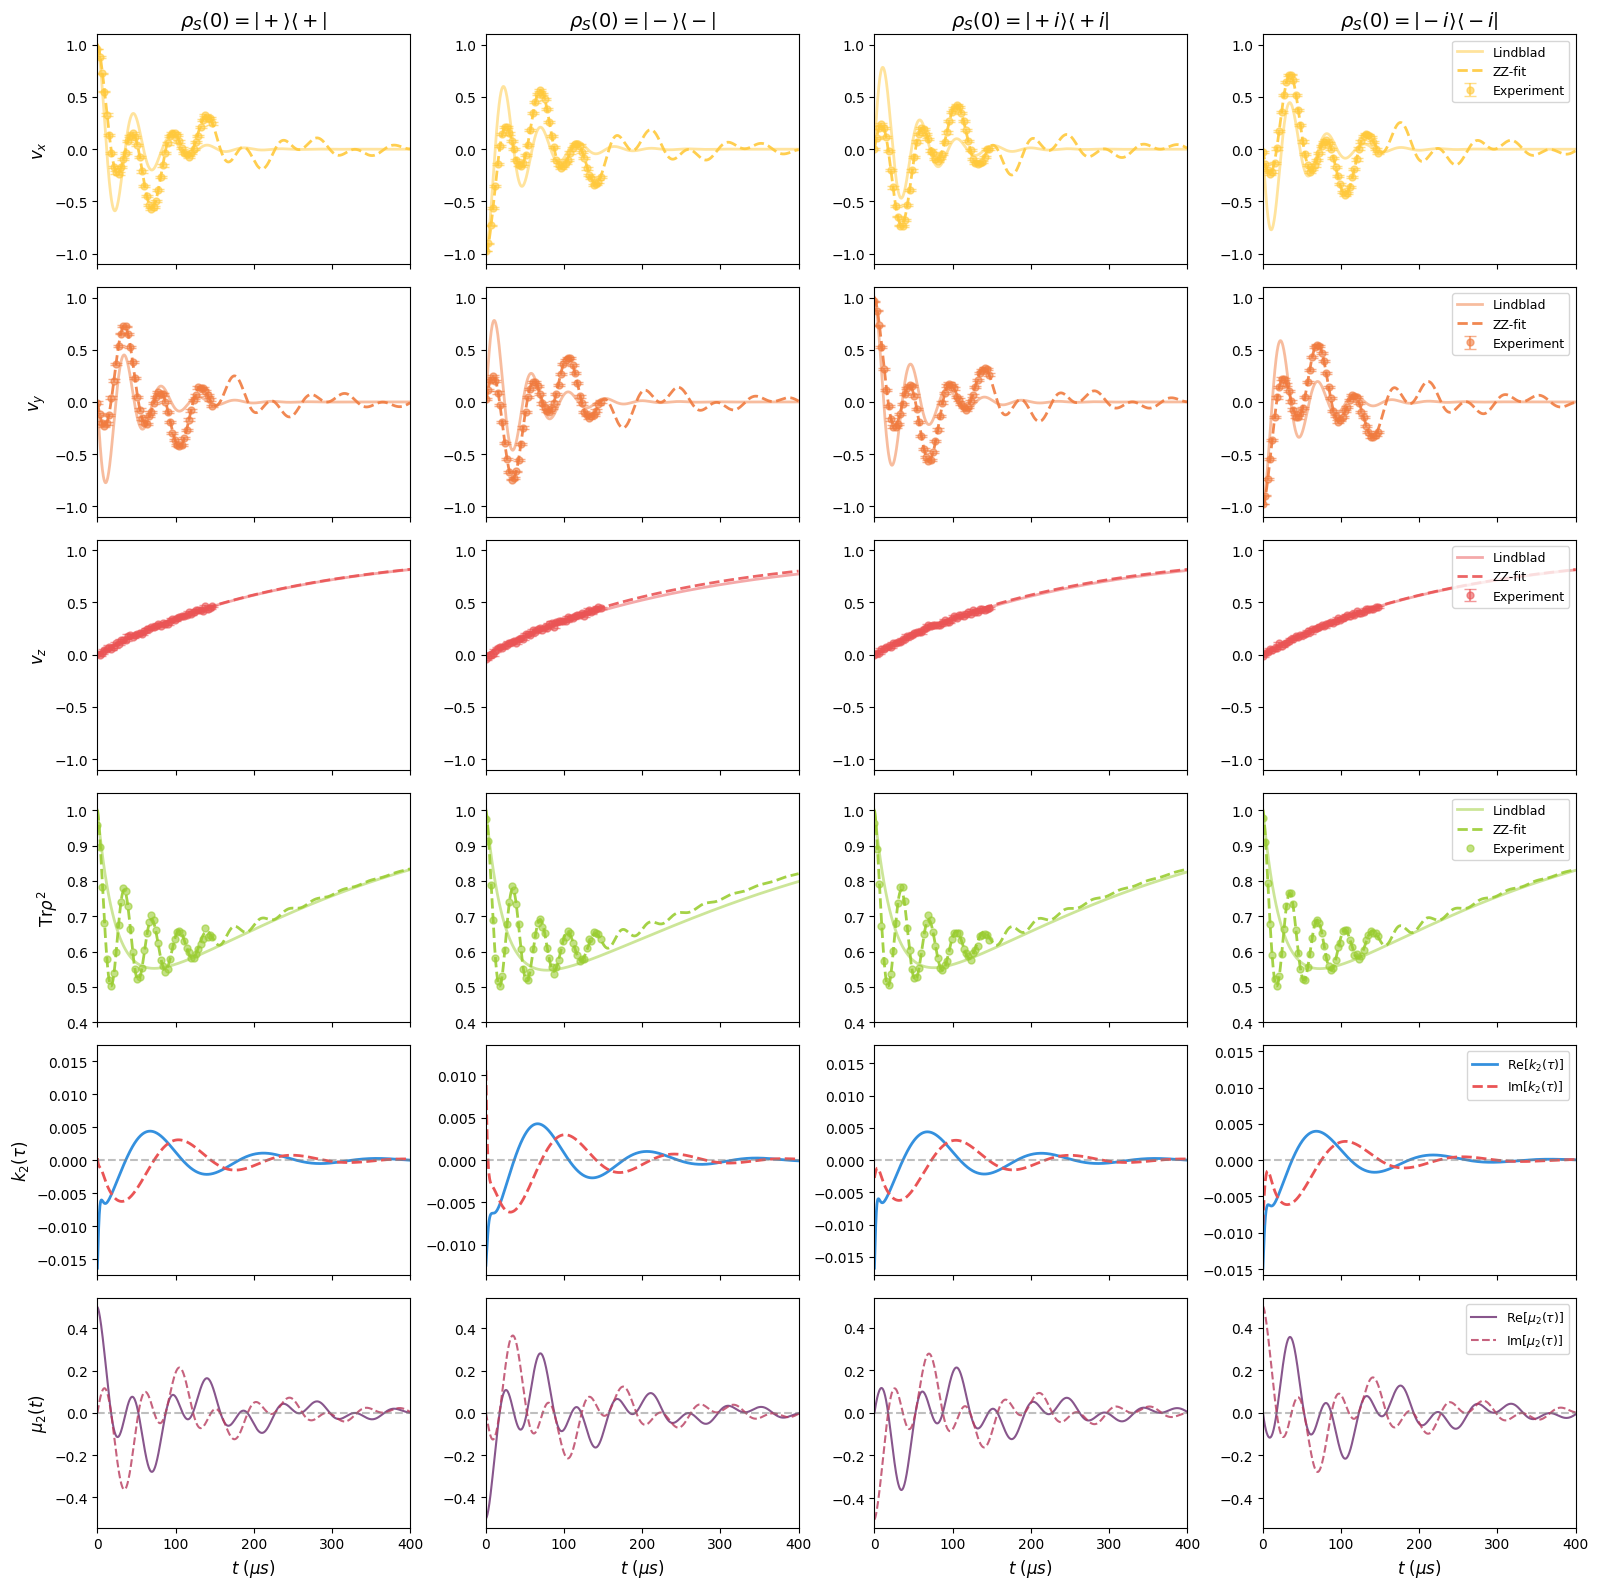

In [6]:
from pathlib import Path
import pandas as pd
import os


file_paths = [
    "results/state_tomography/crosstalk/ibm_brussels/init+,+,+,+/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T16-59-57.csv",
    "results/state_tomography/crosstalk/ibm_brussels/init-,+,+,+/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T17-07-46.csv",
    "results/state_tomography/crosstalk/ibm_brussels/init+i,+,+,+/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T17-15-31.csv",
    "results/state_tomography/crosstalk/ibm_brussels/init-i,+,+,+/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T17-23-17.csv",
]

plot_pmme_kernel_and_state(file_paths, zz_lr=1e-3, t_max_plot=400)


Fitted parameters (physical values)
γ_φ    = 0.00981243
γ_↓    = 0.00390629
ω_0    = 0.113239
Final weighted MSE  = 3.2458e-02


Fitted parameters (physical values)
γ_φ0   = 0.000218948
γ_φ1   = 0.414648
γ_φ2   = 0.0285994
γ_φ3   = 0.0194296
γ_↓    = 0.00377465
J_01   = -0.0929023
J_02   = 0.0809614
J_03   = -0.00141811
ω_0    = -0.0491429
Final weighted MSE  = 1.9273e-02


Fitted parameters (physical values)
γ_φ    = 0.0101402
γ_↓    = 0.00363895
ω_0    = 0.113167
Final weighted MSE  = 3.5652e-02


Fitted parameters (physical values)
γ_φ0   = 9.08956e-05
γ_φ1   = 0.335676
γ_φ2   = 0.0422222
γ_φ3   = 0.0420043
γ_↓    = 0.00370952
J_01   = -0.0791492
J_02   = 0.08393
J_03   = -0.00739578
ω_0    = -0.0349887
Final weighted MSE  = 1.9914e-02


Fitted parameters (physical values)
γ_φ    = 0.00990213
γ_↓    = 0.00400675
ω_0    = 0.112978
Final weighted MSE  = 3.3951e-02


Fitted parameters (physical values)
γ_φ0   = 8.95586e-05
γ_φ1   = 0.413772
γ_φ2   = 0.0288022
γ_φ3   = 0.0215963
γ_↓   

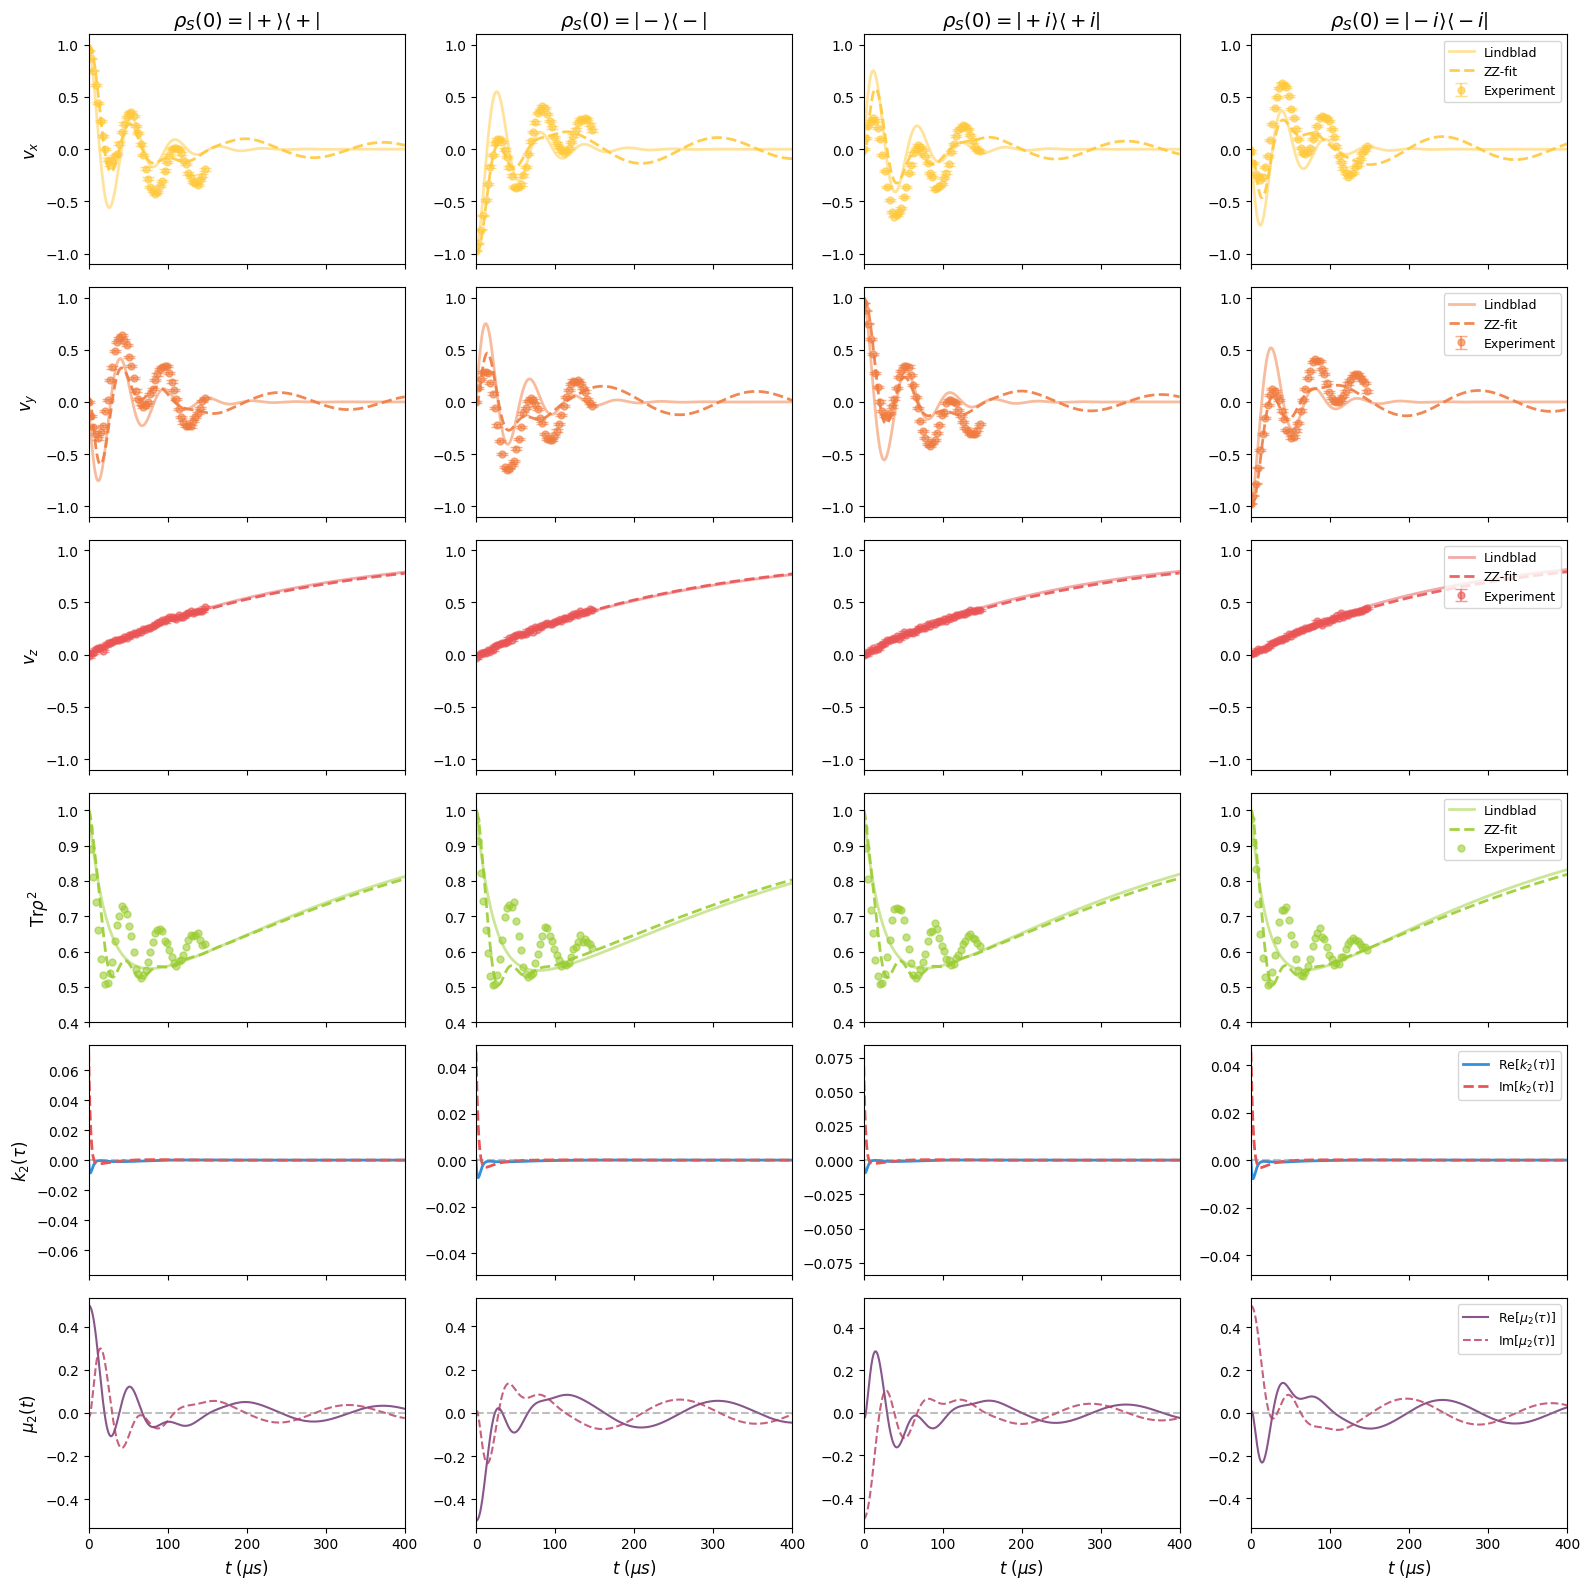

In [5]:
from pathlib import Path
import pandas as pd
import os


file_paths = [
    "results/state_tomography/crosstalk/ibm_brussels/init+,1,1,1/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T20-12-36.csv",
    "results/state_tomography/crosstalk/ibm_brussels/init-,1,1,1/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T20-20-21.csv",
    "results/state_tomography/crosstalk/ibm_brussels/init+i,1,1,1/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T20-28-07.csv",
    "results/state_tomography/crosstalk/ibm_brussels/init-i,1,1,1/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T20-35-53.csv",
]

plot_pmme_kernel_and_state(file_paths, zz_lr=1e-3, t_max_plot=400)


Fitted parameters (physical values)
γ_φ    = 0.00981243
γ_↓    = 0.00390629
ω_0    = 0.113239
Final weighted MSE  = 3.2458e-02


Fitted parameters (physical values)
γ_φ0   = 0.000218948
γ_φ1   = 0.414648
γ_φ2   = 0.0285994
γ_φ3   = 0.0194296
γ_↓    = 0.00377465
J_01   = -0.0929023
J_02   = 0.0809614
J_03   = -0.00141811
ω_0    = -0.0491429
Final weighted MSE  = 1.9273e-02


Fitted parameters (physical values)
γ_φ    = 0.0101402
γ_↓    = 0.00363895
ω_0    = 0.113167
Final weighted MSE  = 3.5652e-02


Fitted parameters (physical values)
γ_φ0   = 9.08956e-05
γ_φ1   = 0.335676
γ_φ2   = 0.0422222
γ_φ3   = 0.0420043
γ_↓    = 0.00370952
J_01   = -0.0791492
J_02   = 0.08393
J_03   = -0.00739578
ω_0    = -0.0349887
Final weighted MSE  = 1.9914e-02


Fitted parameters (physical values)
γ_φ    = 0.00990213
γ_↓    = 0.00400675
ω_0    = 0.112978
Final weighted MSE  = 3.3951e-02


Fitted parameters (physical values)
γ_φ0   = 8.95586e-05
γ_φ1   = 0.413772
γ_φ2   = 0.0288022
γ_φ3   = 0.0215963
γ_↓   

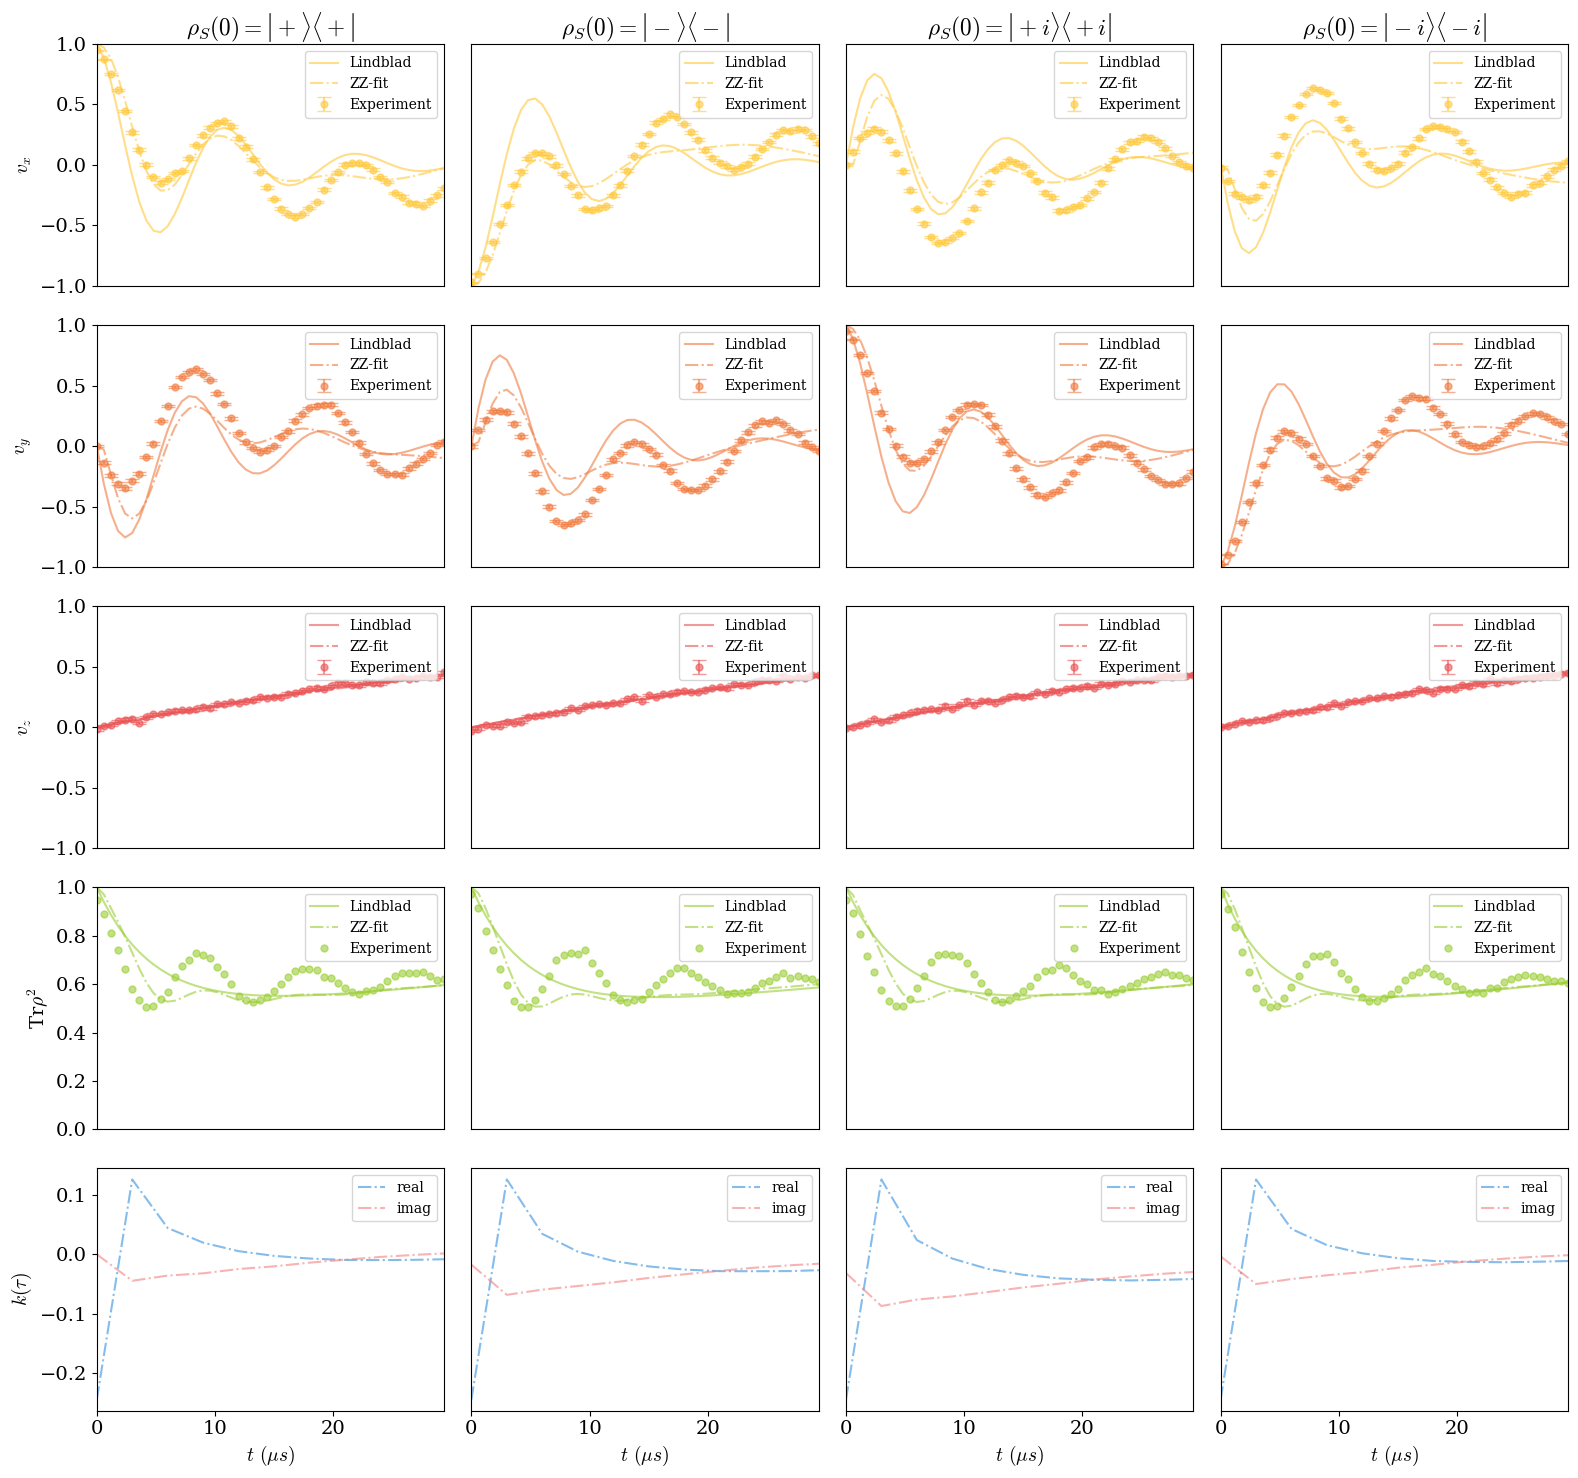

In [ ]:
from pathlib import Path
import pandas as pd
import os


file_paths = [
    "results/state_tomography/crosstalk/ibm_brussels/init+,1,1,1/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T20-12-36.csv",
    "results/state_tomography/crosstalk/ibm_brussels/init-,1,1,1/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T20-20-21.csv",
    "results/state_tomography/crosstalk/ibm_brussels/init+i,1,1,1/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T20-28-07.csv",
    "results/state_tomography/crosstalk/ibm_brussels/init-i,1,1,1/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T20-35-53.csv",
]

plot_pmme_kernel_and_state(file_paths, zz_lr=1e-3, t_max_plot=400)


Fitted parameters for Markov approximation:
ω_z   = 0.13315 (rad/µs)
γ_PD  = 0.01048 (µs⁻¹)
γ_AD  = 0.00425 (µs⁻¹)
Final loss for Markovian approximation = 0.03862536140714421


/opt/anaconda3/envs/qutip-env/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/qutip-env/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)



Fitted parameters for Markov approximation:
ω_z   = -0.04623 (rad/µs)
γ_PD  = 0.01000 (µs⁻¹)
γ_AD  = 0.00401 (µs⁻¹)
Final loss for Markovian approximation = 0.038782004803490686


/opt/anaconda3/envs/qutip-env/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/qutip-env/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)



Fitted parameters for Markov approximation:
ω_z   = 0.13297 (rad/µs)
γ_PD  = 0.00995 (µs⁻¹)
γ_AD  = 0.00422 (µs⁻¹)
Final loss for Markovian approximation = 0.037206150387678764


/opt/anaconda3/envs/qutip-env/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/qutip-env/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)



Fitted parameters for Markov approximation:
ω_z   = 0.13255 (rad/µs)
γ_PD  = 0.01055 (µs⁻¹)
γ_AD  = 0.00422 (µs⁻¹)
Final loss for Markovian approximation = 0.037898734685567904


/opt/anaconda3/envs/qutip-env/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/qutip-env/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


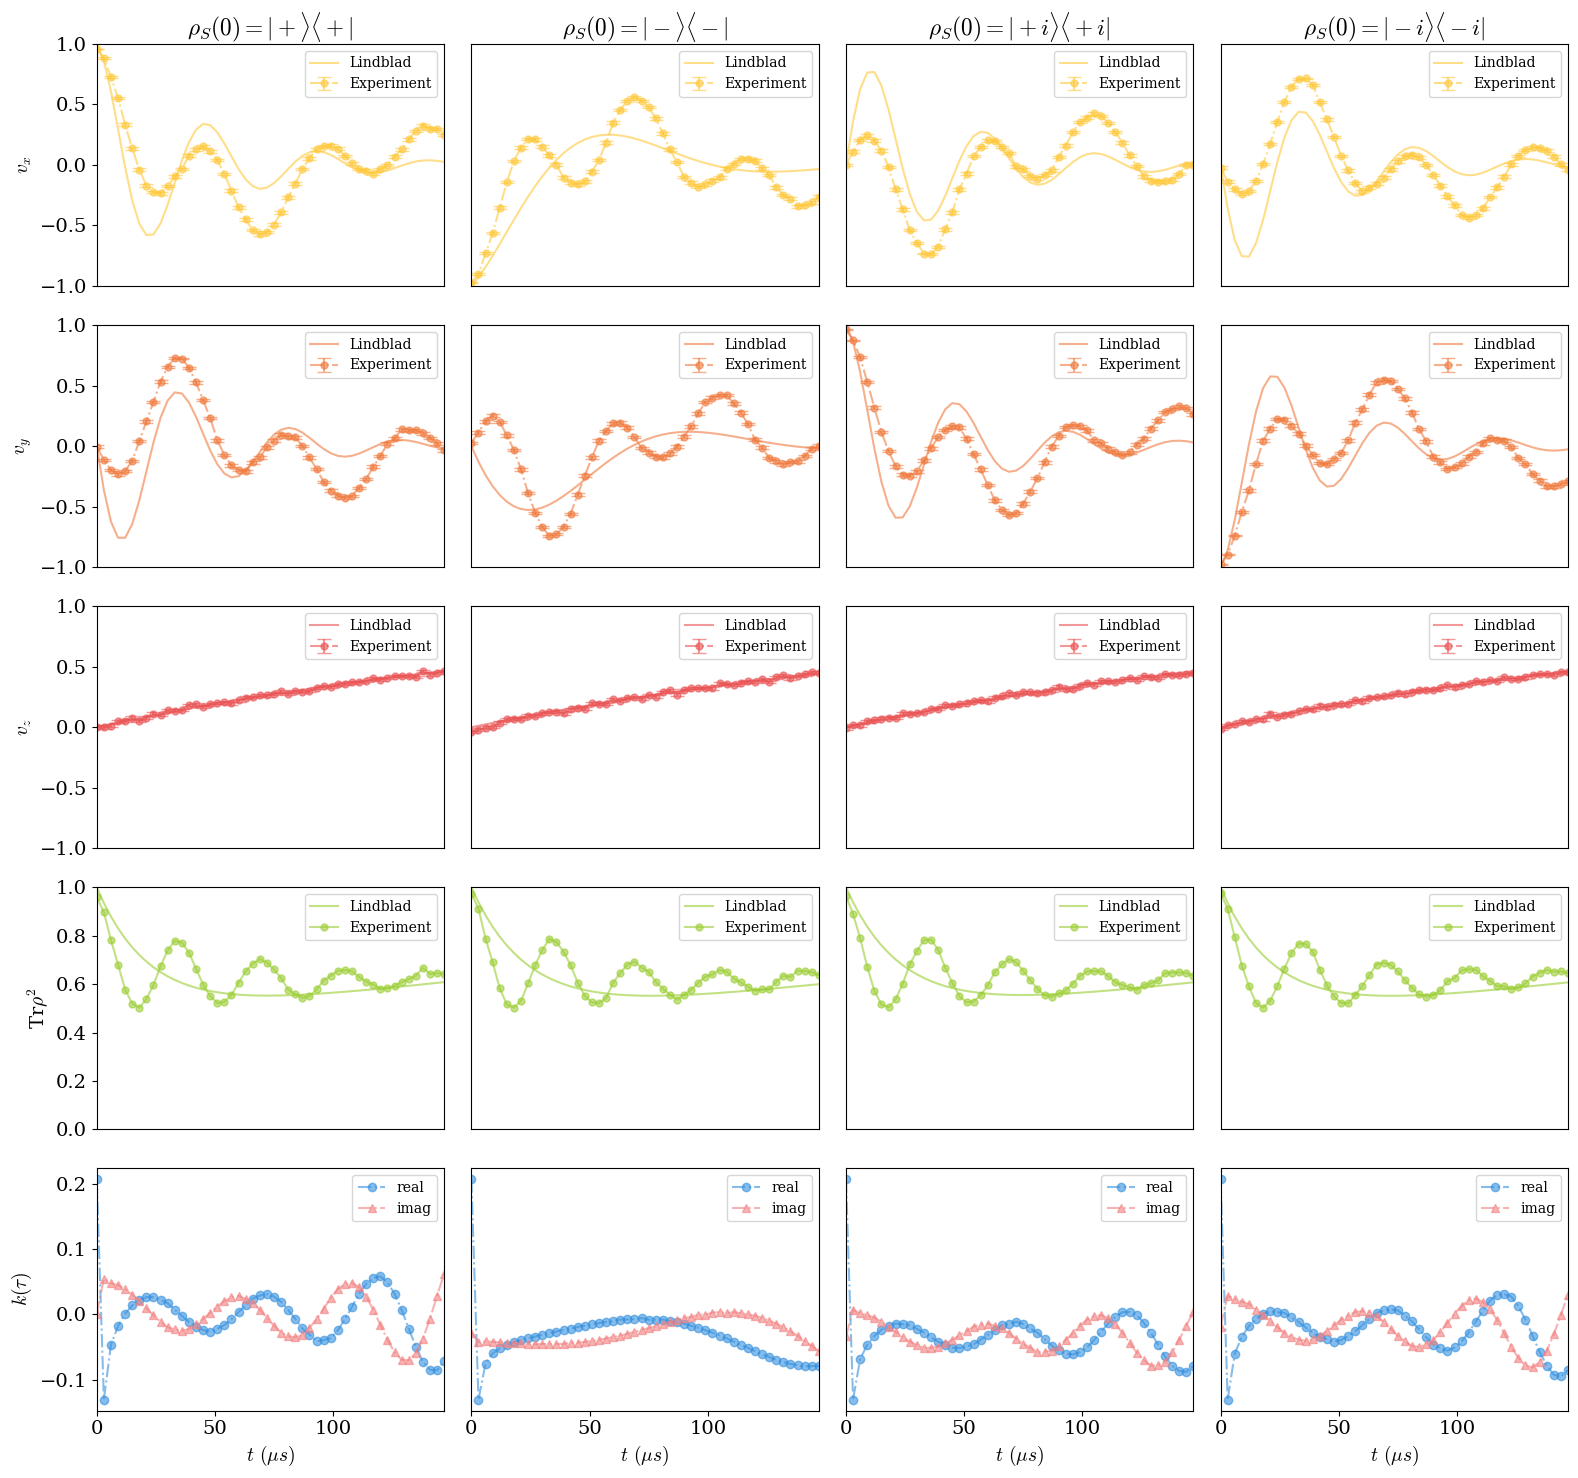

In [ ]:
from pathlib import Path
import pandas as pd
import os

project_root = Path(os.getcwd())

file_paths = [
    "results/state_tomography/crosstalk/ibm_brussels/init+,+,+,+/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T16-59-57.csv",
    "results/state_tomography/crosstalk/ibm_brussels/init-,+,+,+/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T17-07-46.csv",
    "results/state_tomography/crosstalk/ibm_brussels/init+i,+,+,+/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T17-15-31.csv",
    "results/state_tomography/crosstalk/ibm_brussels/init-i,+,+,+/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T17-23-17.csv",
    # "results/state_tomography/crosstalk/ibm_brussels/init+,1,1,1/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T20-12-36.csv",
    # "results/state_tomography/crosstalk/ibm_brussels/init-,1,1,1/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T20-20-21.csv",
    # "results/state_tomography/crosstalk/ibm_brussels/init+i,1,1,1/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T20-28-07.csv",
    # "results/state_tomography/crosstalk/ibm_brussels/init-i,1,1,1/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T20-35-53.csv",
]

plot_pmme_kernel_and_state(file_paths, project_root)

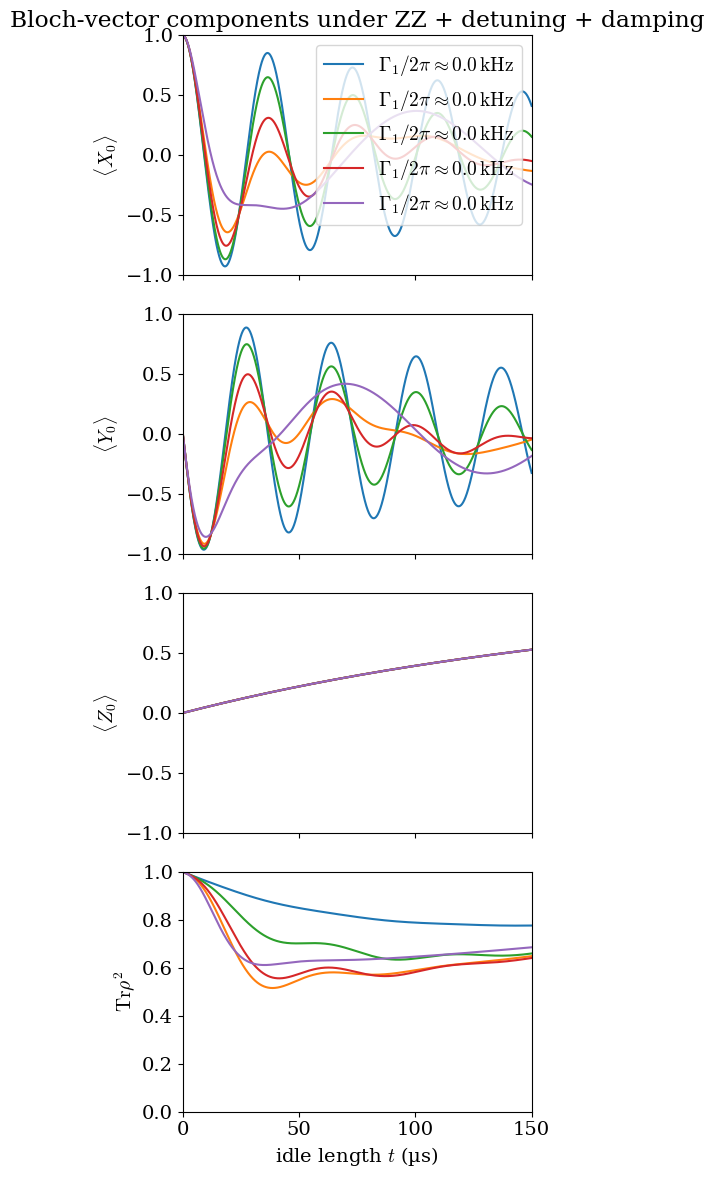

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# -- Exact Appendix‑C block (single spectator) with detuning and damping --

def bloch_components(t, J, Gamma0, Gamma1, omega0):
    """
    Exact Bloch‑vector components from Appendix C (Eq. C21) + detuning.
    """
    Omega = Gamma1/2 - 1j * J
    C = np.cosh(Omega * t)
    S = np.sinh(Omega * t)
    pref = 0.5 * np.exp(-(Gamma0 + Gamma1/2) * t) * np.exp(1j * omega0 * t)
    sigma_plus = pref * (C + ((Gamma1 / 2 + 1j * J) / Omega) * S)
    vx = 2 * sigma_plus.real
    vy = -2 * sigma_plus.imag

    gamma_down0 = 0.005    # assume pure dephasing ~0
    vz = 1 - np.exp(-gamma_down0 * t)

    return vx, vy, vz

# --- Parameters (adjust as needed) ---
J = 0.06              # 13 kHz ZZ
omega0 = 0.112          # 3 kHz detuning
Gamma0 = 0.004           # main‑qubit Γ0 ≈ 12.5 kHz
Gamma1_list = [3e-4, 0.032, 6e-3, 18e-3, 8e-2]   # spectator damping sweep (1–20 kHz)

t = np.linspace(0, 150, 3000)   # 0–150 µs

# --- Plot X, Y, Z components in separate panels ---
fig, axes = plt.subplots(4, 1, figsize=(5, 12), sharex=True)

labels = [f"$\\Gamma_1/2\\pi \\approx {g/2/np.pi:.1f}\\,\\mathrm{{kHz}}$" for g in Gamma1_list]

for Gamma1, lbl in zip(Gamma1_list, labels):
    vx, vy, vz = bloch_components(t, J, Gamma0, Gamma1, omega0)
    axes[0].plot(t, vx, label=lbl)
    axes[1].plot(t, vy)
    axes[2].plot(t, vz)
    axes[3].plot(t, 0.5 * (1 + vx ** 2 + vy ** 2 + vz ** 2))

for ax in axes:
    ax.set_xlim([0, 150])
    ax.set_ylim([-1.0, 1.0])

axes[3].set_ylim([0.0, 1.0])

axes[0].set_ylabel("$\\langle X_0\\rangle$")
axes[1].set_ylabel("$\\langle Y_0\\rangle$")
axes[2].set_ylabel("$\\langle Z_0\\rangle$")
axes[3].set_ylabel("$\\text{Tr}\\rho^2$")
axes[3].set_xlabel("idle length $t$ (µs)")

axes[0].set_title("Bloch‑vector components under ZZ + detuning + damping")
axes[0].legend(loc='upper right')
fig.tight_layout()
plt.show()


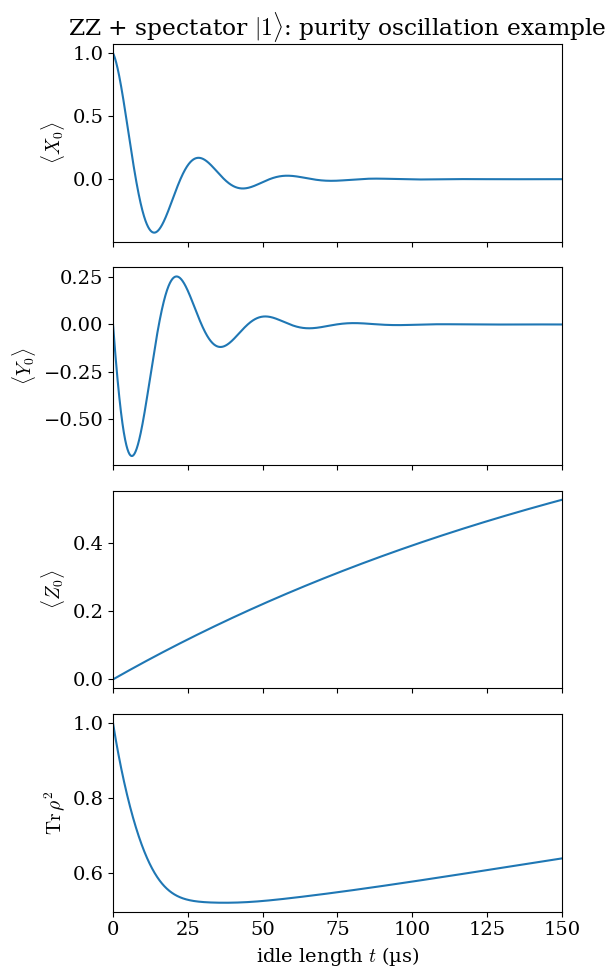

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------- Stable single-spectator ZZ model ----------------------

def sigma_plus_main(t, x0, y0, omega0, Gamma0, J, Gamma1, z_spec=-1.0):
    """
    Numerically stable Σ0⁺(t) for one spectator.
    Units: time in µs, rates in 1/µs, frequencies in rad/µs.

    Σ0⁺(t) = 0.5 (x0 - i y0) e^{-(Γ0 - i ω0)t} * F_spec(t)
    with spectator factor written in bounded form to avoid overflow:
      e^{-Γ1 t/2}cosh(Ω t) = 0.5 (e^{-i J t} + e^{-Γ1 t} e^{+i J t})
      e^{-Γ1 t/2}sinh(Ω t) = 0.5 (e^{-i J t} - e^{-Γ1 t} e^{+i J t})
    where Ω = Γ1/2 - i J.
    """
    t = np.asarray(t)
    Sigma = 0.5 * (x0 - 1j*y0) * np.exp(-(Gamma0 - 1j*omega0) * t)

    e_imJt  = np.exp(-1j * J * t)
    e_pimJt = np.exp(+1j * J * t)
    e_mGt   = np.exp(-Gamma1 * t)

    cosh_part = 0.5 * (e_imJt + e_mGt * e_pimJt)
    sinh_part = 0.5 * (e_imJt - e_mGt * e_pimJt)

    Omega = Gamma1/2.0 - 1j*J
    eps = 1e-12
    ratio = np.where(np.abs(Omega) > eps,
                     (Gamma1/2.0 - 1j*z_spec*J) / Omega,
                     (Gamma1/2.0 - 1j*z_spec*J))  # benign fallback

    spectator_factor = cosh_part + ratio * sinh_part
    return Sigma * spectator_factor


def bloch_components(t, J, Gamma0, Gamma1, omega0,
                     gamma_down0,
                     x0=1.0, y0=0.0, z0=0.0, z_spec=-1.0):
    """Bloch components for the main qubit + one spectator."""
    Sigma = sigma_plus_main(t, x0, y0, omega0, Gamma0, J, Gamma1, z_spec=z_spec)
    vx =  2.0 * Sigma.real
    vy = -2.0 * Sigma.imag
    vz = 1.0 + (z0 - 1.0) * np.exp(-gamma_down0 * t)  # main-qubit T1
    return vx, vy, vz


def purity(vx, vy, vz):
    """One-qubit purity from Bloch vector."""
    return 0.5 * (1.0 + vx**2 + vy**2 + vz**2)

# -------------------------- Example that oscillates --------------------------

# Time grid (µs)
t = np.linspace(0.0, 150.0, 3000)

# Default parameters that reproduce clear purity oscillations for spectator |1>
# (You can paste these directly into your fitting code as good initial guesses.)
J            = 0.100   # rad/µs   (≈ 9.5 kHz)
Gamma1       = 0.010   # 1/µs     spectator envelope  (≈ 32 kHz)
Gamma0       = 0.05   # 1/µs     main envelope (≈ 2*γφ0 + 0.5*γ↓0)
omega0       = 0.112   # rad/µs   small detuning (≈ 18 kHz)
gamma_down0  = 0.005   # 1/µs     main T1^{-1}  (T1 ≈ 200 µs)

# Main in |+> (x0=1,y0=0,z0=0); spectator in |1> ⇒ z_spec = -1
vx, vy, vz = bloch_components(
    t, J, Gamma0, Gamma1, omega0, gamma_down0,
    x0=1.0, y0=0.0, z0=0.0, z_spec=-1.0
)
P = purity(vx, vy, vz)

# ------------------------------ Plot ----------------------------------------

fig, axes = plt.subplots(4, 1, figsize=(6, 10), sharex=True)
axes[0].plot(t, vx); axes[0].set_ylabel(r'$\langle X_0\rangle$')
axes[1].plot(t, vy); axes[1].set_ylabel(r'$\langle Y_0\rangle$')
axes[2].plot(t, vz); axes[2].set_ylabel(r'$\langle Z_0\rangle$')
axes[3].plot(t, P);  axes[3].set_ylabel(r'$\mathrm{Tr}\,\rho^2$')
axes[3].set_xlabel('idle length $t$ (µs)')

for ax in axes:
    ax.set_xlim(0, 150)
axes[0].set_title('ZZ + spectator $|1\\rangle$: purity oscillation example')
plt.tight_layout()
plt.show()

# ----------------------- Two more presets (optional) ------------------------
# Uncomment to compare other oscillatory regimes you might observe.
# presets = [
#     {"J": 0.050, "Gamma1": 0.029},  # slightly longer period, similar envelope
#     {"J": 0.070, "Gamma1": 0.036},  # shorter period, a bit more damped
# ]
# for p in presets:
#     vx, vy, vz = bloch_components(t, p["J"], Gamma0, p["Gamma1"], omega0, gamma_down0)
#     plt.figure(figsize=(6,3.2))
#     plt.plot(t, purity(vx, vy, vz))
#     plt.xlabel('t (µs)'); plt.ylabel(r'$\mathrm{Tr}\,\rho^2$')
#     plt.title(f'Purity: J={p["J"]:.3f} rad/µs, Γ1={p["Gamma1"]:.3f} 1/µs')
#     plt.tight_layout(); plt.show()


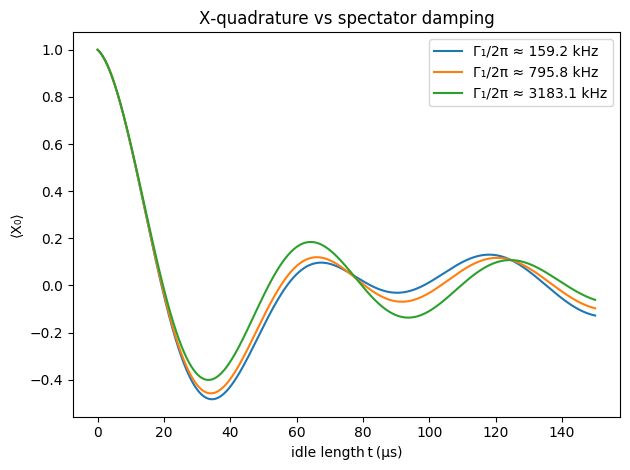

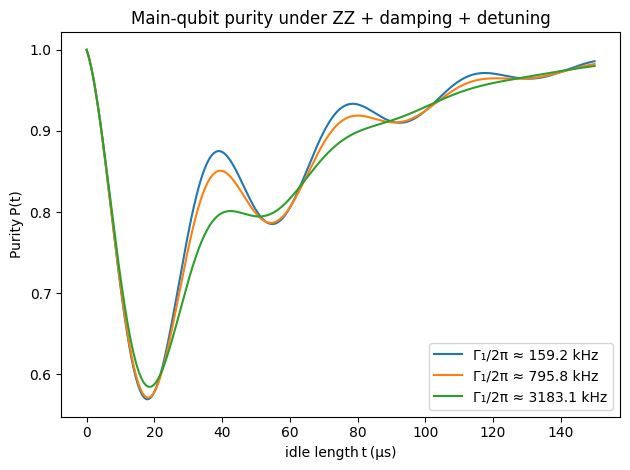

In [146]:
import numpy as np
import matplotlib.pyplot as plt

# === Exact single‑spectator ZZ model (Appendix C, Eq. C21) + detuning and amplitude damping ===
def bloch_components(t, J, Gamma0, Gamma1, omega0):
    """
    Exact Bloch‑vector components of the main qubit for the initial state |+>_0 |+>_1
    under the full Lindbladian (ZZ + amplitude damping + dephasing) and a static detuning ω0.
    Uses Eq. (C21) of the Appendix plus a Z‑rotation e^{-iω0 t}.
    
    Parameters
    ----------
    t : ndarray
        Time grid (s).
    J : float
        ZZ coupling (rad/s).
    Gamma0 : float
        Total dephasing+damping rate on main qubit (1/s)  [Γ0  = γ↓0/2 + 2γϕ0].
    Gamma1 : float
        Amplitude‑damping rate on spectator (1/s)          [Γ1  = γ↓1].
    omega0 : float
        Additional detuning on main qubit (rad/s).
    """
    # Complex frequency Ω  = Γ1/2 − i J
    Omega = Gamma1/2 - 1j * J
    # Convenience shorthands
    C = np.cosh(Omega * t)
    S = np.sinh(Omega * t)
    prefactor = 0.5 * np.exp(-(Gamma0 + Gamma1/2) * t) * np.exp(-1j * omega0 * t)
    # Eq. C21:  Σ₀⁺(t)
    sigma_plus = prefactor * (C + (Gamma1 / (2 * Omega)) * S)
    vx = 2 * sigma_plus.real
    vy = -2 * sigma_plus.imag
    
    # Z component of main qubit under amplitude damping γ↓0 = 2 (Γ0 − 2γϕ0).
    #  Take γ↓0 = 2Γ0   (assuming negligible pure dephasing for simplicity).
    gamma_down0 = 2 * Gamma0
    vz = 1 - np.exp(-gamma_down0 * t)  #  Z(0)=0 → |+⟩; approaches +1
    
    # Purity of reduced state  ½(1 + r²)
    r2 = vx**2 + vy**2 + vz**2
    purity = 0.5 * (1 + r2)
    
    return vx, vy, vz, purity

# ----- Parameter sweep -----
J = 2 * np.pi * 13e3        # 13 kHz
omega0 = 2 * np.pi * 3e3    # 3 kHz detuning
Gamma0 = 1/80e-6            # ~12.5 kHz  (T1 ≈ 160 µs, no pure dephasing)
Gamma1_list = [1e3, 5e3, 20e3]   # spectator damping: 1, 5, 20 kHz

t = np.linspace(0, 150e-6, 3000)    # 0–150 µs

fig1 = plt.figure()
for Gamma1 in Gamma1_list:
    vx, vy, vz, purity = bloch_components(t, J, Gamma0, Gamma1, omega0)
    plt.plot(t*1e6, vx, label=f"Γ₁/2π ≈ {Gamma1/2/np.pi:.1f} kHz")
plt.xlabel("idle length t (µs)")
plt.ylabel("⟨X₀⟩")
plt.title("X‑quadrature vs spectator damping")
plt.legend()
plt.tight_layout()

fig2 = plt.figure()
for Gamma1 in Gamma1_list:
    vx, vy, vz, purity = bloch_components(t, J, Gamma0, Gamma1, omega0)
    plt.plot(t*1e6, purity, label=f"Γ₁/2π ≈ {Gamma1/2/np.pi:.1f} kHz")
plt.xlabel("idle length t (µs)")
plt.ylabel("Purity P(t)")
plt.title("Main‑qubit purity under ZZ + damping + detuning")
plt.legend()
plt.tight_layout()

plt.show()


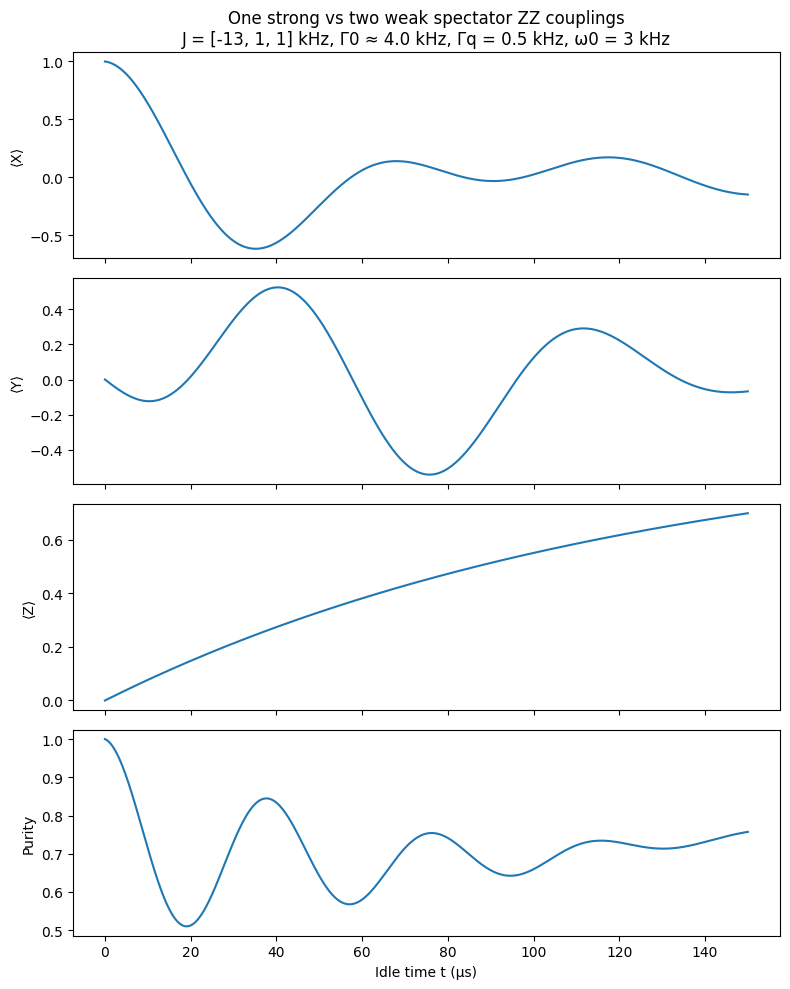

In [151]:
import numpy as np
import matplotlib.pyplot as plt

def sigma_plus_multi(t, J_list, Gamma0, Gamma_list, omega0):
    pref = np.exp(-Gamma0 * t) * np.exp(-1j * omega0 * t)
    prod = np.ones_like(t, dtype=complex)
    for Jq, Gq in zip(J_list, Gamma_list):
        Omega_q = Gq/2 - 1j*Jq
        prod *= np.exp(-Gq*t/2) * np.cosh(Omega_q * t)
    return 0.5 * pref * prod

def bloch_and_purity(t, J_list, Gamma0, Gamma_list, omega0):
    sigma = sigma_plus_multi(t, J_list, Gamma0, Gamma_list, omega0)
    vx = 2*sigma.real
    vy = -2*sigma.imag
    vz = 1 - np.exp(-2*Gamma0*t)
    purity = 0.5 * (1 + vx**2 + vy**2 + vz**2)
    return vx, vy, vz, purity

# Parameters
J_kHz = [-13, 1, 1]
J_list = 2*np.pi*np.array(J_kHz)*1e3  # rad/s
Gamma0 = 1/250e-6                     # 4 kHz
Gamma_list = np.full(3, 0.5e3)        # 0.5 kHz each spectator
omega0 = -2*np.pi*3e3                  # 3 kHz detuning

t = np.linspace(0, 150e-6, 4000)
vx, vy, vz, purity = bloch_and_purity(t, J_list, Gamma0, Gamma_list, omega0)

# Plot
fig, axes = plt.subplots(4, 1, figsize=(8, 10), sharex=True)
labels = ["⟨X⟩", "⟨Y⟩", "⟨Z⟩", "Purity"]
for ax, data, lab in zip(axes, [vx, vy, vz, purity], labels):
    ax.plot(t*1e6, data)
    ax.set_ylabel(lab)
axes[3].set_xlabel("Idle time t (µs)")
axes[0].set_title("One strong vs two weak spectator ZZ couplings\n"
                  f"J = {J_kHz} kHz, Γ0 ≈ {Gamma0/1e3:.1f} kHz, Γq = 0.5 kHz, ω0 = 3 kHz")
plt.tight_layout()
plt.show()


LBFGS done. Final loss=1.889e-02

Fitted parameters (physical values)
γ_φ0   = 1.68373e-08
γ_φ1   = 0.0262805
γ_φ2   = 9.20955
γ_φ3   = 0.449549
γ_↓    = 0.00379855
J_01   = 0.080839
J_02   = 0.417645
J_03   = -0.117132
ω_0    = 0.342979
Final weighted MSE  = 1.8885e-02



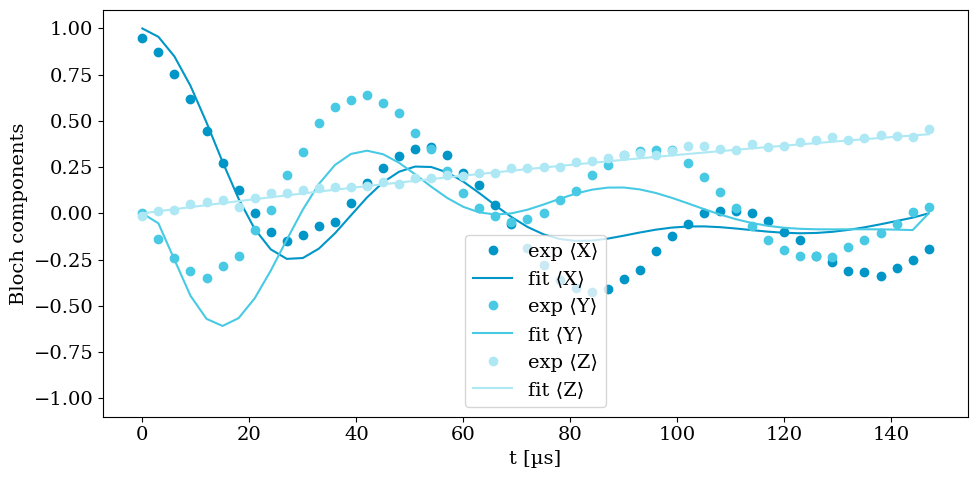

Array([ 1.68373195e-08,  2.62805124e-02,  9.20955417e+00,  4.49548978e-01,
        3.79855334e-03,  8.08389738e-02,  4.17644822e-01, -1.17132023e-01,
        3.42979340e-01], dtype=float64)

In [21]:
from pathlib import Path

import jax, jax.numpy as jnp
import optax
import pandas as pd
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

# -----------------------------------------------------------------------------
#  Utility : initial‑state parsing
# -----------------------------------------------------------------------------

def _state_to_bloch(label: str):
    """Return (x,y,z) Bloch coords for |+>, |->, |0>, |1>."""
    label = label.strip()
    if label == "+":
        return 1.0, 0.0, 0.0
    if label == "-":
        return -1.0, 0.0, 0.0
    if label == "+i":
        return 0.0, 1.0, 0.0
    if label == "-i":
        return 0.0, -1.0, 0.0
    if label == "0":
        return 0.0, 0.0, 1.0
    if label == "1":
        return 0.0, 0.0, -1.0
    raise ValueError(f"Unknown qubit label '{label}'.")


def parse_initial_state(path: str | Path, n_spec: int):
    """Extract main and spectator Bloch vectors from filename."""
    path = str(path)
    try:
        init_chunk = path.split("init")[1].split("/")[0]     # '+,+,+,+'
    except IndexError as e:
        raise RuntimeError("Filename must contain 'init<prep_string>/' segment") from e

    labels = init_chunk.split(",")
    if len(labels) != n_spec + 1:
        raise ValueError(
            f"Expected {n_spec+1} qubit labels, found {len(labels)} in '{init_chunk}'.")

    # main qubit first
    x0, y0, z0 = _state_to_bloch(labels[0])
    spectator_xyz = jnp.array([_state_to_bloch(l) for l in labels[1:]])  # (N,3)
    z_spec = spectator_xyz[:, 2]                                          # (N,)
    return jnp.asarray([x0, y0, z0], dtype=jnp.float64), z_spec

# -----------------------------------------------------------------------------
#  Analytic Σ₀⁺(t) and Bloch‑vector functions (Eq. C58)
# -----------------------------------------------------------------------------

def sigma_plus_general(t, x0, y0, ω0, Γ0, J_0q, Γq, zq):
    """Analytic Σ₀⁺(t) for arbitrary spectator preparations.

    t : (T,)          time grid
    x0,y0            : main‑qubit Bloch coords in xy plane at t=0
    ω0               : detuning (rad/µs)
    Γ0               : envelope rate (½γ↓₀ + γϕ₀)
    J_0q, Γq, zq : (N,)   : ZZ couplings, spectator decay, spectator z‑coords
    """
    t = t[None, :]                     # broadcast (1,T)
    Σ = 0.5 * (x0 - 1j * y0) * jnp.exp(-(Γ0 - 1j * ω0) * t)

    if J_0q.size:
        Jq = J_0q[:, None]
        Γq = Γq[:, None]
        zq = zq[:, None]
        Ωq  = Γq / 2.0 - 1j * Jq
        Cq  = jnp.cosh(Ωq * t)
        Sq  = jnp.sinh(Ωq * t)
        bracket = Cq + ((Γq / 2.0 - 1j * zq * Jq) / Ωq) * Sq
        Σ *= jnp.exp(-Γq * t / 2.0).prod(axis=0) * bracket.prod(axis=0)

    return Σ.squeeze(0)               # (T,)


def bloch_from_parameters(t, init_config, θ, n_spec):
    """Decode parameter vector θ → Bloch vector array (3,T)."""
    
    bloch_main = init_config["bloch-main"]
    x0, y0, z0 = bloch_main
    z_spec = init_config["z-spec"]
    
    γ_φ  = jnp.abs(θ[:n_spec+1])     # dephasing rate
    γ_down = jnp.abs(θ[n_spec+1])    # amplitude damping rate
    J_0q = θ[n_spec+2: 2*n_spec+2]   # ZZ crosstalk strength
    ω_0 = θ[2*n_spec+2]
    
    Γ_0 = 2 * γ_φ[0] + 0.5 * γ_down
    Γ_q = γ_φ[1:]
    

    Σ  = sigma_plus_general(t, x0, y0, ω_0, Γ_0, J_0q, Γ_q, z_spec)
    vx =  2.0 * Σ.real
    vy = -2.0 * Σ.imag
    vz = 1 + (z0 - 1) * jnp.exp(-γ_down * t)

    return jnp.stack([vx, vy, vz])    # (3,T)

# -----------------------------------------------------------------------------
#  Fitting routine
# -----------------------------------------------------------------------------

def fit_crosstalk(csv_path: str | Path,
                  n_spec: int,
                  lr: float = 1e-2,
                  steps: int = 5000,
                  seed: int = 0,
                  plot: bool = False,
                  verbose: bool = False):
    """Fit ZZ‑crosstalk parameters to a CSV containing Bloch trajectories."""
    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path)

    t_exp = jnp.asarray(df.iloc[:, 0].to_numpy(), dtype=jnp.float64)
    bloch_exp = jnp.asarray(df[["X_mean", "Y_mean", "Z_mean"]].to_numpy().T,
                            dtype=jnp.float64)  # (3,T)

    bloch0_main, z_spec_init = parse_initial_state(csv_path, n_spec)
    init_config = {
        'bloch-main': bloch0_main, # list of bloch vectors 
        'z-spec': z_spec_init,     # list of pauli Z expectation of spectator qubits
    }

    # ---- build initial θ --------------------------------------------------
    key = jax.random.PRNGKey(seed)
    θ   = jax.random.normal(key, (3 + 2 * n_spec,)) * 0.05  # small noise

    # ---- loss -------------------------------------------------------------
    def loss_fn(θ):
        pred = bloch_from_parameters(t_exp, init_config, θ, n_spec)
        return jnp.mean((pred - bloch_exp) ** 2)

    # opt = optax.adam(lr)
    # opt_state = opt.init(θ)

    # @jax.jit
    # def step(θ, opt_state):
    #     l, g = jax.value_and_grad(loss_fn)(θ)
    #     updates, opt_state = opt.update(g, opt_state, θ)
    #     θ = optax.apply_updates(θ, updates)
    #     return θ, opt_state, l

    # for k in range(steps):
    #     θ, opt_state, L = step(θ, opt_state)
    #     if verbose and k % 100 == 0:
    #         print(f"[{k:5d}] loss = {float(L):.5e}")
    
    # Create the LBFGS gradient transformation (note: works best with value & grad passing)
    lbfgs = optax.lbfgs(memory_size=30)
    vg_fn = optax.value_and_grad_from_state(loss_fn)
    state = lbfgs.init(θ)

    def body(carry, _):
        params, state = carry
        value, grad = vg_fn(params, state=state)
        updates, state = lbfgs.update(grad, state, params,
                                      value=value, grad=grad, value_fn=loss_fn)
        params = optax.apply_updates(params, updates)
        return (params, state), value

    (θ, _), losses_lbfgs = jax.lax.scan(body,
                                        (θ, state),
                                        xs=None,
                                        length=10000)

    final_loss = float(loss_fn(θ))
    if verbose:
        print(f"LBFGS done. Final loss={final_loss:.3e}")

    # ---- results ----------------------------------------------------------
    names = [
        *[f"γ_φ{q}" for q in range(0, n_spec+1)], 
        "γ_↓",
        *[f"J_0{q}" for q in range(1, n_spec + 1)],
        "ω_0",
    ]

    print("\nFitted parameters (physical values)")
    θ = θ.at[:n_spec+2].set(jnp.abs(θ[:n_spec+2]))
    
    
    for n, v in zip(names, θ):
        print(f"{n:6s} = {float(v):.6g}")

    print(f"Final weighted MSE  = {float(loss_fn(θ)):.4e}\n")

    if plot:
        bloch_fit = bloch_from_parameters(t_exp, init_config, θ, n_spec)
        col = ["#0096c7", "#48cae4", "#ade8f4"]
        plt.figure(figsize=(10, 5))
        for i, pauli in enumerate("XYZ"):
            plt.plot(t_exp, bloch_exp[i], "o", color=col[i], label=f"exp ⟨{pauli}⟩")
            plt.plot(t_exp, bloch_fit[i],   "-", color=col[i], label=f"fit ⟨{pauli}⟩")
        plt.xlabel("t [µs]"); plt.ylabel("Bloch components"); plt.ylim([-1.1, 1.1])
        plt.legend(); plt.tight_layout(); plt.show()

    return θ


fit_crosstalk(
    # csv_path="results/state_tomography/crosstalk/ibm_brussels/init+,+,+,+/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T16-59-57.csv",
    csv_path="results/state_tomography/crosstalk/ibm_brussels/init+,1,1,1/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T20-12-36.csv",
    n_spec=3,
    lr=1e-3,
    steps=100000,
    seed=42,
    plot=True,
    verbose=True
)


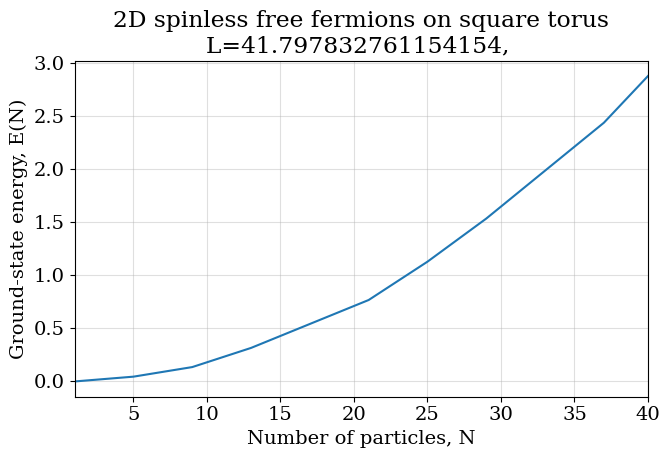

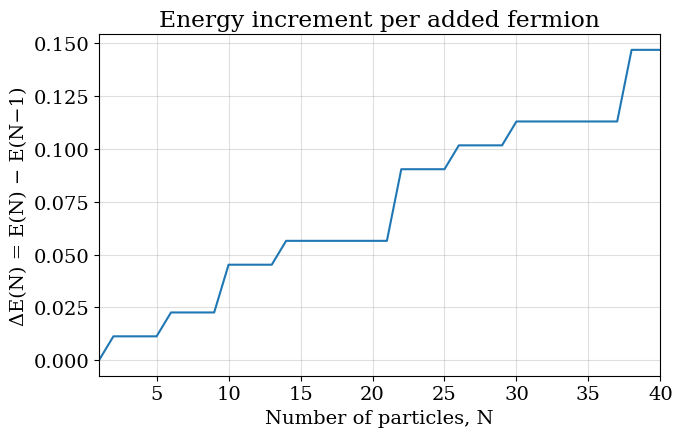

In [14]:
# Add back L parameter; keep option to include or drop the prefactor.
# Default demo plots *without* prefactor (dimensionless), as requested.

import numpy as np
import matplotlib.pyplot as plt
import math


def spectrum(N_max: int, L: float = 1.0, include_prefactor: bool = False):
    """
    Compute E(N) and ΔE(N) for non-interacting spinless fermions on a 2D L×L torus.
    ħ = m = 1. If include_prefactor=True, multiply by ½(2π/L)²; otherwise return
    the dimensionless sums over n_x²+n_y².
    Returns: N, E(N), ΔE(N), n2_sorted, prefactor_used
    """
    # minimal square in (n_x, n_y) holding at least N_max modes
    M = 0
    while (2*M + 1)**2 < N_max:
        M += 1

    n = np.arange(-M, M + 1, dtype=int)
    NX, NY = np.meshgrid(n, n, indexing="ij")
    n2 = (NX**2 + NY**2).ravel()

    order = np.argsort(n2, kind="mergesort")  # stable sort to group degeneracies
    n2_sorted = n2[order][:N_max].astype(float)

    E_dimless = np.cumsum(n2_sorted, dtype=float)
    dE_dimless = np.diff(np.concatenate(([0.0], E_dimless)))
    pref = 0.5 * (2.0 * np.pi / L)**2

    if include_prefactor:
        E = pref * E_dimless
        dE = pref * dE_dimless
    else:
        E = E_dimless
        dE = dE_dimless

    N = np.arange(1, N_max + 1, dtype=int)
    return N, E, dE, n2_sorted, (pref if include_prefactor else 1.0)

def plot_E_and_dE(N, E, dE, L: float, include_prefactor: bool):
    # Title suffix clarifies whether prefactor is applied
    suffix = f"L={L}, "
    # Plot E(N)
    plt.figure(figsize=(6.8, 4.8))
    plt.plot(N, E)
    plt.xlabel("Number of particles, N")
    ylabel = "Ground-state energy, E(N)"
    plt.ylabel(ylabel)
    plt.title(f"2D spinless free fermions on square torus\n{suffix}")
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.xlim([1, N[-1]])
    plt.show()

    # Plot ΔE(N)
    plt.figure(figsize=(6.8, 4.6))
    plt.plot(N, dE)
    plt.xlabel("Number of particles, N")
    plt.ylabel("ΔE(N) = E(N) − E(N−1)" + ("" if include_prefactor else " (dimensionless)"))
    plt.title("Energy increment per added fermion")
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.xlim([1, N[-1]])
    plt.show()

# ---------------- DEMO up to N = 40 (no prefactor), with L parameter kept ----------------
N_max_demo = 40
L_demo = 30.0 * math.sqrt(33/17)
include_prefactor_demo = True  # set True if you want physical units

N, E, dE, n2_sorted, pref_used = spectrum(N_max_demo, L=L_demo, include_prefactor=include_prefactor_demo)
plot_E_and_dE(N, E, dE, L=L_demo, include_prefactor=include_prefactor_demo)
